In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [59]:
def readData(filepath):
  data = pd.read_csv(filepath)
  components = ["x", "y", "z"]

  centers = []
  pdf = []

  for _, c in enumerate(components):
    temp_centers = ((data[f"v_{c:s}_lower"] + data[f"v_{c:s}_upper"]) / 2).to_numpy()
    counts = data[f"v_{c:s}"]
    total = np.trapezoid(counts, temp_centers)
    centers.append(temp_centers)
    pdf.append(counts / total)
  return data, pdf, centers

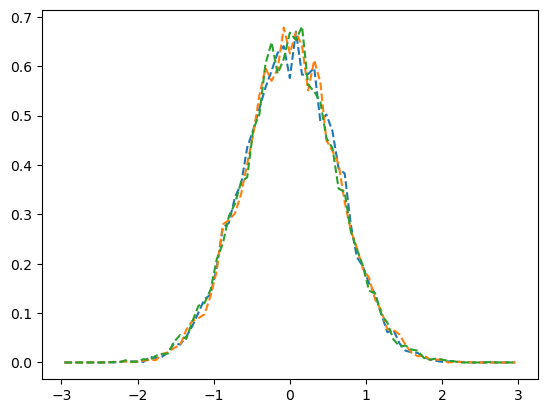

In [60]:
_, pdfs, centers = readData("testing_csv_distribution_2000.csv")
plt.figure()
for i, (pdf, center) in enumerate(zip(pdfs, centers)):
  plt.plot(center, pdf, '--', label=f"{i:d}")
plt.show()

In [61]:
from scipy.constants import k as k_B
def rayleigh(x, mass, temperature):
  R =  k_B / mass
  return x / (R * temperature) * np.exp(-x**2 / (2 * R * temperature))

def maxwellian(x, mass, temperature):
  R = k_B / mass
  return 1 / (np.sqrt(2 * np.pi * R * temperature)) * np.exp(-x**2 / (2 * R * temperature))

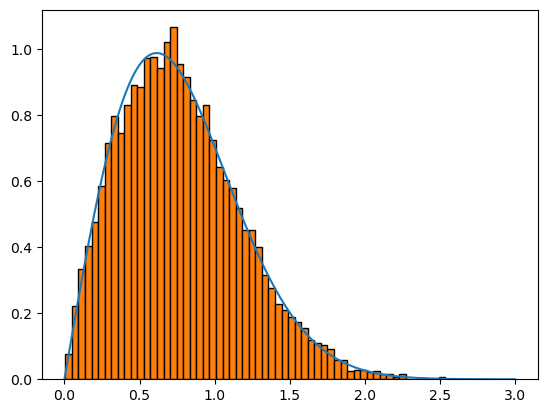

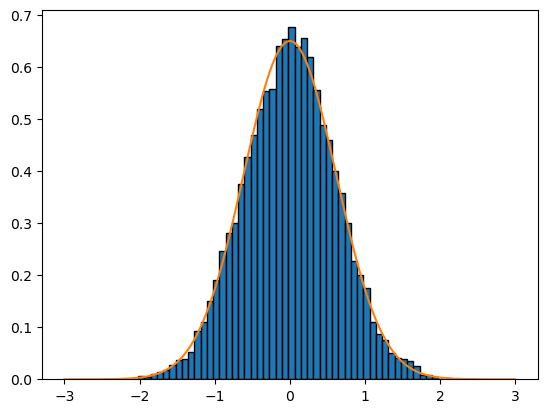

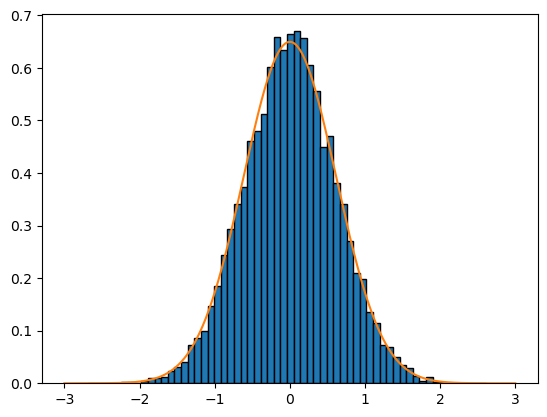

In [62]:
data = pd.read_csv("testing_csv_particles_0001.csv")
counts, edges = np.histogram(data["v_z"].to_numpy(), bins=75, density=True)
centers = edges[1:] - edges[:-1]
mass = 1e-20
temperature = 273.15

v_range = np.linspace(0,3, 1000)
plt.figure()
plt.plot(v_range, rayleigh(v_range, mass, temperature))
plt.hist(np.abs(data["v_x"]), bins=60, edgecolor='k', density=True)
plt.show()


max_v_range = np.linspace(-3, 3, 1000)
plt.figure()
plt.hist(data["v_y"], bins=60, edgecolor='k', density=True)
plt.plot(max_v_range, maxwellian(max_v_range, mass, temperature))
plt.show()


plt.figure()
plt.hist(data["v_z"], bins=60, edgecolor='k', density=True)
plt.plot(max_v_range, maxwellian(max_v_range, mass, temperature))
plt.show()